# Signal Quality

Quantile diagnostics replace the legacy Alphalens dependency.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tree_model_utils import (
    FEATURES,
    compare_bagging,
    ensure_output_dir,
    fit_decision_tree,
    fit_signal_model,
    long_short_backtest,
    make_equity_panel,
    signal_quality,
    tune_random_forest,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_equity_panel(seed=117)
_, scored, diagnostics = fit_signal_model(panel)
quality = signal_quality(scored)
quality.to_csv(OUTPUT / 'signal_quality_by_bucket.csv', index=False)
quality

,bucket,mean,std,count
0,1,0.0012,0.0325,2752
1,2,0.0022,0.0368,2752
2,3,0.0037,0.0346,2752
3,4,0.0057,0.0337,2752
4,5,0.0046,0.0356,2752


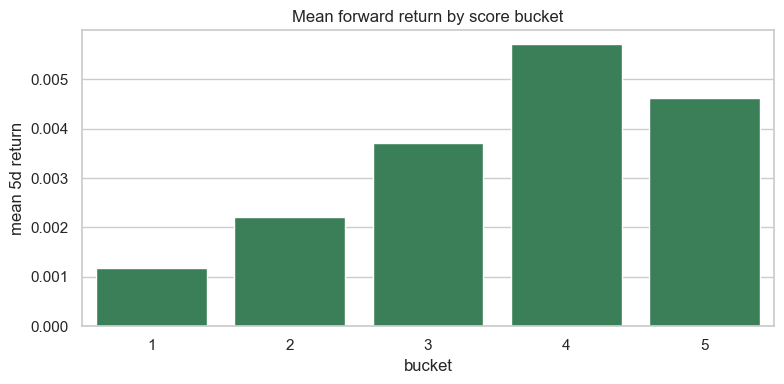

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=quality, x='bucket', y='mean', ax=ax, color='seagreen')
ax.set(title='Mean forward return by score bucket', ylabel='mean 5d return')
plt.tight_layout()